In [21]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict,Annotated
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
import operator

In [4]:
load_dotenv()
llm=ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite-preview")

In [6]:
essay="""Technology has become a key driver of modern governance, transforming how governments interact with citizens and deliver public services. In a country like India, with its vast population and diversity, technology helps bridge gaps in accessibility, transparency, and efficiency.

One of the most significant contributions of technology is in enhancing transparency. Digital platforms such as online portals for public services reduce human intervention, thereby minimizing corruption and delays. Initiatives like direct benefit transfer ensure that subsidies reach beneficiaries without leakage.

Technology also improves service delivery. E-governance systems allow citizens to access services like applying for documents, paying taxes, or filing complaints from their homes. This reduces administrative burden and saves time for both citizens and officials.

However, challenges remain. The digital divide between urban and rural areas limits equal access to these benefits. Issues of data privacy and cybersecurity also need strong regulatory frameworks.

In conclusion, while technology has immense potential to strengthen governance, its success depends on inclusive implementation, robust infrastructure, and awareness among citizens. Properly utilized, it can lead to more accountable and citizen-centric governance."""

In [7]:
class FeedbackSchema(BaseModel):
    feedback:str=Field(description="Detailed Feedbac for the Essay")
    score: int=Field(description="Score Out of 10",le=10,ge=0)

In [8]:
structure_llm=llm.with_structured_output(FeedbackSchema)

In [9]:
class UPSCState(TypedDict):
    essay:str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback:str
    overall_feedback:str 
    individual_scores: Annotated[list[int],operator.add]
    overall_score:int

In [16]:
def evaluate_langauage(state:UPSCState):
    
    essay=state["essay"]
    prompt=PromptTemplate(
        template="""Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}""",
        input_variables=["essay"]
    ) 
    chain=prompt| structure_llm
    
    res=chain.invoke({"essay":essay}) 
    return  {'language_feedback': res.feedback, 'individual_scores': [res.score]}    

In [17]:
def evaluate_thought(state:UPSCState):
    
    essay=state["essay"]
    prompt=PromptTemplate(
        template="""Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {essay}""",
        input_variables=["essay"]
    ) 
    chain=prompt| structure_llm
    
    res=chain.invoke({"essay":essay}) 
    return  {'clarity_feedback': res.feedback, 'individual_scores': [res.score]}   

In [18]:
def evaluate_analysis(state:UPSCState):
    
    essay=state["essay"]
    prompt=PromptTemplate(
        template="""Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {essay}""",
        input_variables=["essay"]
    ) 
    chain=prompt| structure_llm
    
    res=chain.invoke({"essay":essay}) 
    return  {'analysis_feedback': res.feedback, 'individual_scores': [res.score]}   

In [19]:
def evuluate_summary(state:UPSCState):
    
    essay=state["essay"]
    language_feedback=state["language_feedback"]
    clarity_feedback=state["clarity_feedback"]
    analysis_feedback=state["analysis_feedback"]
    
    prompt=PromptTemplate(
        template="""Based on the following feedbacks create a summarized feedback \n language feedback - {language_feedback} \n depth of analysis feedback - {analysis_feedback} \n clarity of thought feedback - {clarity_feedback}""",
        input_variables=["language_feedback","analysis_feedback","clarity_feedback"]
    ) 
    chain=prompt| llm
    
    res=chain.invoke({"language_feedback":language_feedback,"analysis_feedback":analysis_feedback,"clarity_feedback":clarity_feedback})
    avg_score=sum(state["individual_scores"])/len(state["individual_scores"])
    
    return {"overall_feedback":res.content,"overall_score":avg_score}
    

In [22]:
# Graph
graph =StateGraph(UPSCState)

# Add Node
graph.add_node("evaluate_langauage",evaluate_langauage)
graph.add_node("evaluate_thought",evaluate_thought)
graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_summary",evuluate_summary)


# Add Edges
graph.add_edge(START,"evaluate_langauage")
graph.add_edge(START,"evaluate_thought")
graph.add_edge(START,"evaluate_analysis")

graph.add_edge("evaluate_langauage","evaluate_summary")
graph.add_edge("evaluate_thought","evaluate_summary")
graph.add_edge("evaluate_analysis","evaluate_summary")

graph.add_edge("evaluate_summary",END)


# Compile 
workflow=graph.compile()

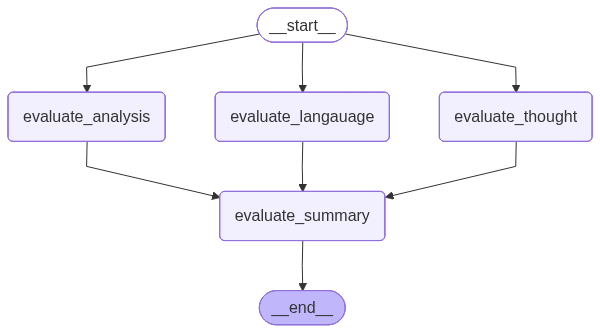

In [23]:
workflow

In [24]:
res=workflow.invoke({"essay":essay})

In [28]:
print(res['essay'])

Technology has become a key driver of modern governance, transforming how governments interact with citizens and deliver public services. In a country like India, with its vast population and diversity, technology helps bridge gaps in accessibility, transparency, and efficiency.

One of the most significant contributions of technology is in enhancing transparency. Digital platforms such as online portals for public services reduce human intervention, thereby minimizing corruption and delays. Initiatives like direct benefit transfer ensure that subsidies reach beneficiaries without leakage.

Technology also improves service delivery. E-governance systems allow citizens to access services like applying for documents, paying taxes, or filing complaints from their homes. This reduces administrative burden and saves time for both citizens and officials.

However, challenges remain. The digital divide between urban and rural areas limits equal access to these benefits. Issues of data privacy

In [29]:
print(res['analysis_feedback'])

The essay provides a solid overview of the role of technology in modern governance, specifically within the Indian context. It effectively identifies key benefits such as increased transparency through digital portals and improved service delivery via e-governance. However, the analysis remains somewhat superficial. It touches upon challenges like the digital divide and cybersecurity but does not explore the underlying causes, specific policy failures, or nuanced socio-economic implications. To improve, the essay would benefit from concrete case studies, a deeper discussion on the policy frameworks (e.g., Digital India), and a more critical evaluation of the trade-offs between surveillance and efficiency.


In [30]:
print(res['clarity_feedback'])

The essay demonstrates excellent clarity of thought. It follows a logical structure, beginning with a clear thesis, supporting it with specific, relevant examples (such as direct benefit transfer), acknowledging counterarguments regarding the digital divide, and providing a balanced conclusion. The language is professional and concise. To achieve a perfect score, the essay could have explored the 'how' behind the regulatory frameworks or provided a more nuanced look at the socio-political implications of technology in governance.


In [31]:
print(res['language_feedback'])

The essay is well-structured, clear, and concise. It effectively addresses the topic by highlighting both the benefits and the challenges of technology in governance. The grammar is excellent, the vocabulary is appropriate for a formal context, and the flow between paragraphs is logical. To improve further, the writer could provide specific, real-world examples (such as mentioning the 'Aadhaar' or 'UPI' platforms specifically in the Indian context) to strengthen the arguments.


In [32]:
print(res['individual_scores'])

[6, 9, 9]


In [33]:
print(res['overall_feedback'])

[{'type': 'text', 'text': 'Here is a summarized feedback for the essay:\n\n### **Summary Feedback**\n\n**Strengths:**\nThe essay is well-structured, professional, and logically coherent, demonstrating excellent clarity of thought and effective communication. It provides a solid overview of technology’s role in modern Indian governance, successfully highlighting key benefits such as improved service delivery and increased transparency. The writing style is formal and precise, with a clear thesis and a balanced approach to the subject matter.\n\n**Areas for Improvement:**\nWhile the essay is structurally sound, the analysis remains somewhat superficial. To elevate the work, consider the following enhancements:\n\n*   **Integrate Concrete Evidence:** Move beyond general observations by incorporating specific real-world examples, such as the ‘Aadhaar’ or ‘UPI’ platforms, to substantiate your claims.\n*   **Deepen the Analysis:** Shift from a descriptive overview to a critical evaluation. E

In [34]:
print(res['overall_score'])

8.0
